# Aula 03: kNN e busca de hiperparâmetros

Nesta atividade, vamos abordar o problema de detecção de diabetes a partir de um conjunto de atributos pessoais (como idade) e medidas relacionadas ao organismo de cada pessoa (como a pressão sanguínea).

*Dataset*: https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data


In [ ]:
""" Importando os pacotes necessários """

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.impute import SimpleImputer

#opção: SMOTE para aumentar artificialmente a quantidade de amostras da classe minoritária
from imblearn.over_sampling import SMOTE

## 1. Baixando o *dataset* do Github

In [ ]:
""" Carregando o dataset do Github para trabalhar autonomamente no Colab """

import requests
from pathlib import Path

# Caminho para a pasta que conterá o dataset
data_path = Path("data/")

# Se o diretório ainda não existe, criamos e baixamos o dataset
if data_path.is_dir():
    print(f"O diretório {data_path} já existe")
else:
    print(f"Diretório {data_path} não localizado, criando um ...")
    data_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / "diabetes.csv", "wb") as f:
        request = requests.get("https://github.com/EA991-Lab/utils/raw/main/data/diabetes.csv")
        print("Baixando os dados ...")
        f.write(request.content)

Diretório data não localizado, criando um ...
Baixando os dados ...


## 2. Análise inicial do *dataset*

In [ ]:
""" Carregamos o dataset e analisamos algumas de suas características """

#leitura do arquivo completo de dados
data = pd.read_csv(data_path / "diabetes.csv")

#dicionário para mapear as classes nos números desejados
labels = {0: 'Normal', 1: 'Diabetes'}

#acrescenta a coluna 'labels' mapeando os valores de 'Outcome' conforme o dicionário criado
data['labels'] = data['Outcome'].map(labels)

#nomes das classes
class_names = ['Normal','Diabetes']

#visualização de parte inicial do dataset
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,labels
0,6,148,72,35,0,33.6,0.627,50,1,Diabetes
1,1,85,66,29,0,26.6,0.351,31,0,Normal
2,8,183,64,0,0,23.3,0.672,32,1,Diabetes
3,1,89,66,23,94,28.1,0.167,21,0,Normal
4,0,137,40,35,168,43.1,2.288,33,1,Diabetes


### 2.1 Balanceamento das classes

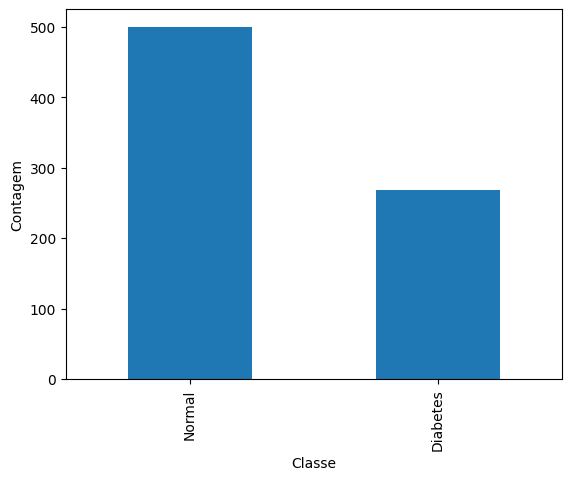

In [ ]:
""" Histograma da coluna 'labels' """
plt.figure()
pd.Series(data['labels']).value_counts().plot(kind = 'bar')
plt.ylabel("Contagem")
plt.xlabel("Classe")
plt.show()

### 2.2 Estatísticas básicas dos atributos

In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.3 Histogramas por atributo

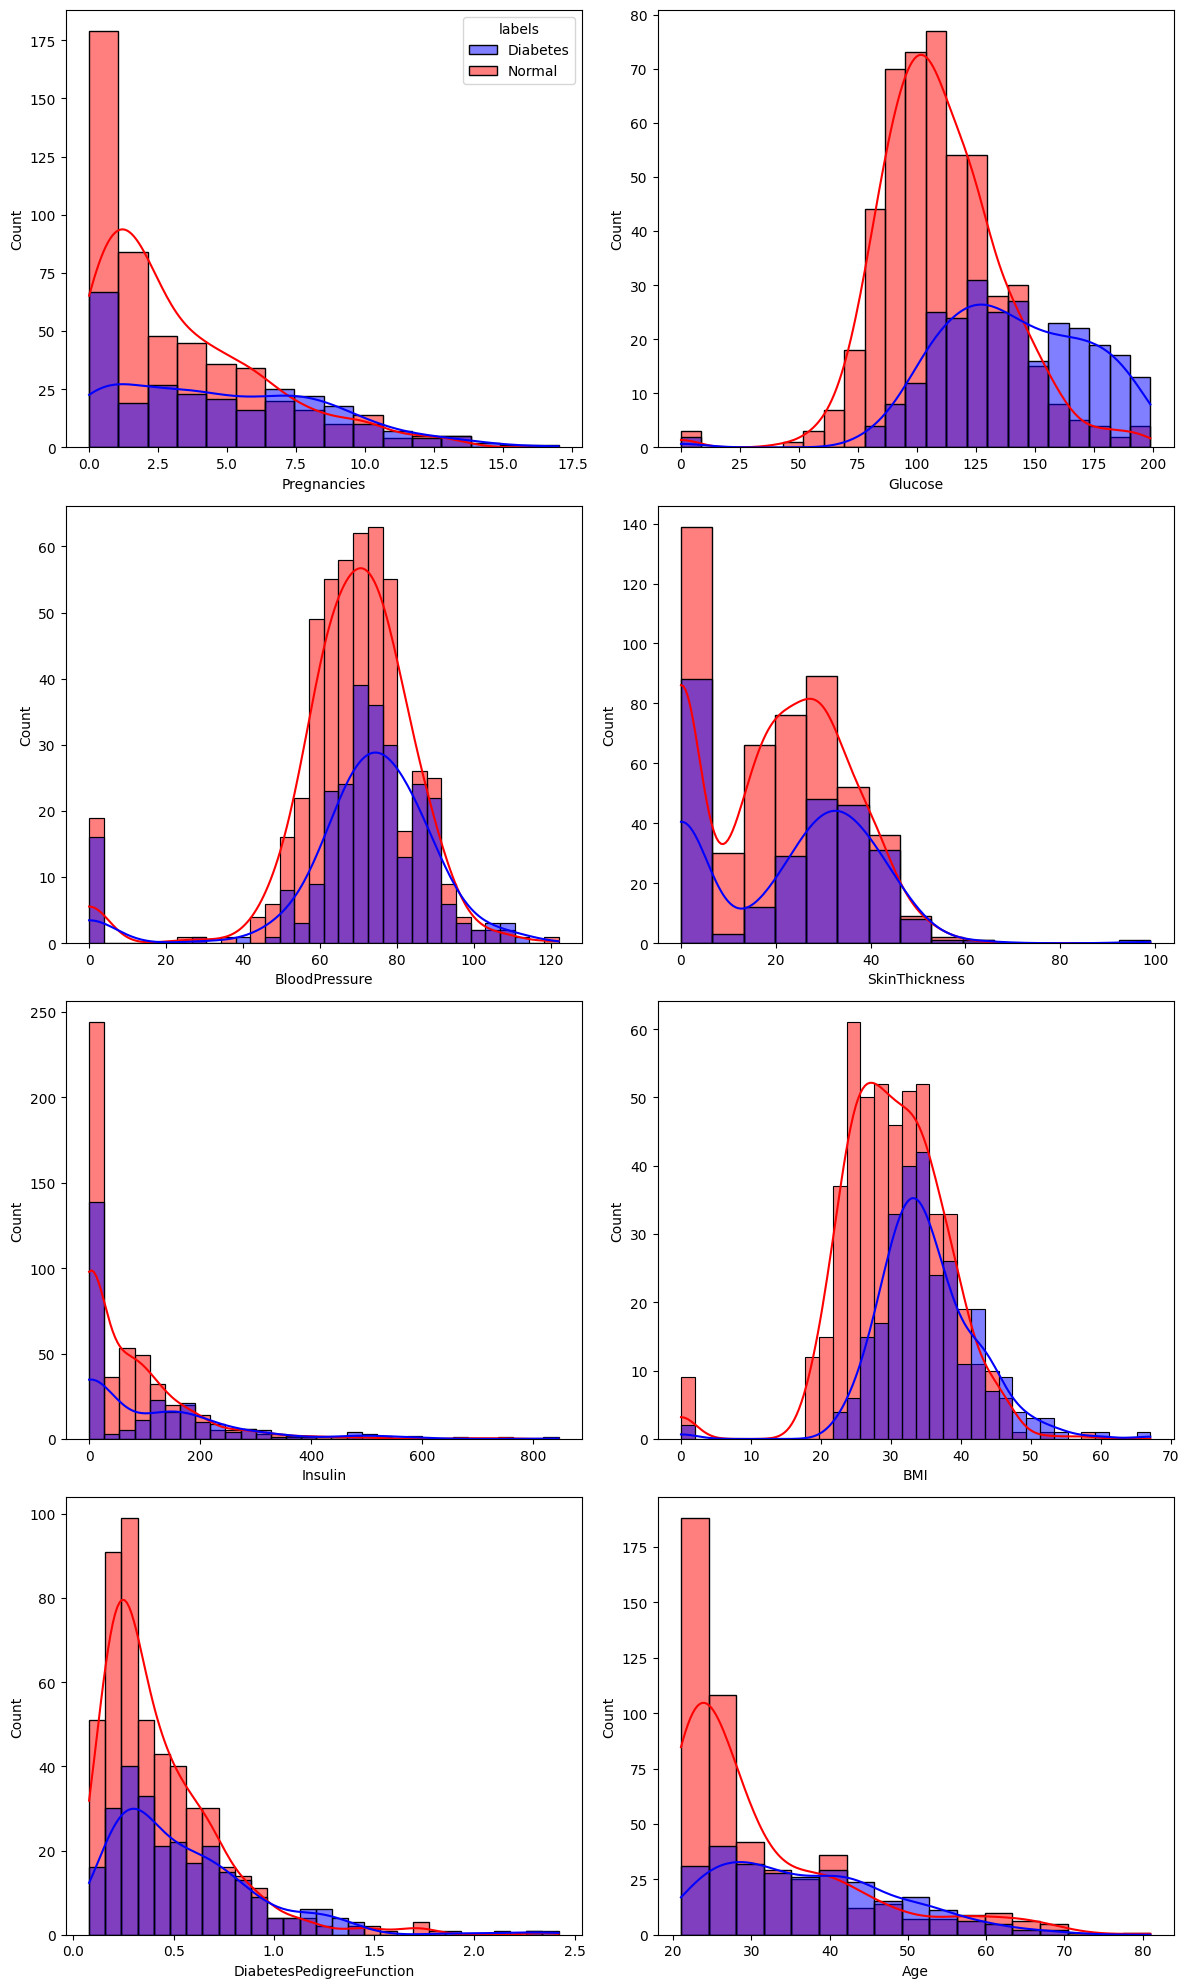

In [ ]:
""" Histogramas por atributo """
fig, axs = plt.subplots(4, 2, figsize=(12, 20))
for col, ax in zip(data.columns[:-2], axs.flat):
    sns.histplot(data=data, x=col, kde=True, hue='labels', common_norm=False, palette = ['blue','red'],legend=ax==axs[0,0], ax=ax)
plt.tight_layout()
plt.show()

### 2.4 Pré-processamento: valores faltantes

É possível notar a aparição de valores nulos indevidos para alguns atributos, como 'BloodPressure'. Nestes casos, vamos substituir por `NaN` para, depois, usar uma técnica de imputação.

In [ ]:
#colunas com atributos faltantes
missing_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
#substituímos os 0s por NaN
data[missing_columns] = data[missing_columns].replace(to_replace=0.0, value=np.nan)

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,labels
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,Diabetes
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,Normal
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,Diabetes
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Normal
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Diabetes


## 3. Preparação do conjunto de dados

Nesta primeira parte, vamos adotar a estratégia mais simples de validação cruzada, a saber, *holdout*.

Passos:
- Divisão em treinamento, validação e teste;
- Imputação e normalização.

**Observação:** o conjunto de teste é ajustado a partir das informações derivadas do conjunto de treinamento (ou de treinamento + validação).

In [ ]:
#extrai os atributos de entrada do DataFrame
X = data.iloc[:,:-2]
#extrai do DataFrame os rótulos numéricos
y = data["Outcome"]


#opção: stratify = y - separa as amostras mantendo a proporção que os labels originalmente têm (no caso, 1/3, 1/3 e 1/3)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1,stratify=y)

""" Imputação e normalização dos atributos """
imputer = SimpleImputer()
scaler = StandardScaler()

#faz a imputação dos valores nas partições de treinamento e teste
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

#em seguida, aplica a normalização
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#X_train_scaled = X_train
#X_test_scaled = X_test
#separa do conjunto de treinamento original uma parcela para servir como validação
X_train_part, X_val_scaled, y_train_part, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=1,stratify=y_train)

print(f"Dimensões das partições de dados\n")
print(f"Conjunto de treinamento: {X_train_part.shape}")
print(f"Conjunto de validação: {X_val_scaled.shape}")
print(f"Conjunto de teste: {X_test.shape}")



Dimensões das partições de dados

Conjunto de treinamento: (491, 8)
Conjunto de validação: (123, 8)
Conjunto de teste: (154, 8)


## 4. kNN

### 4.1 Treinamento e acompanhamento do desempenho no conjunto de validação em função do número de vizinhos (*k*)

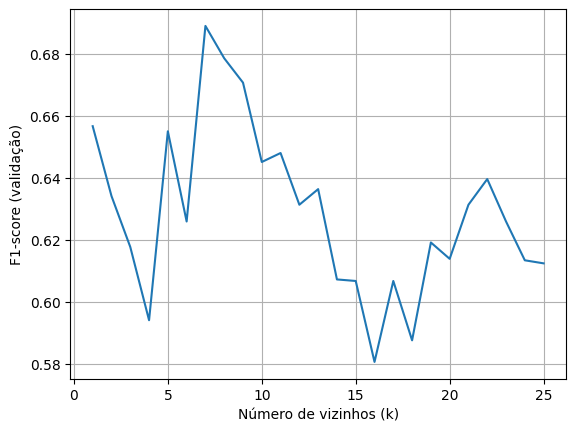

In [ ]:
#método de ponderação dos votos dos vizinhos mais próximos
weights = 'uniform'
#número máximo de vizinhos
max_k = 25

#inicialização
result_f1score = np.zeros((max_k,))
f1_val = []

#número de vizinhos mais próximos será variado
for k in range(1,max_k+1):

    #criamos uma instância do Nearest Neighbours e ajustamos aos dados de treinamento
    clf = KNeighborsClassifier(k, weights=weights)

    #treinamento na partição exclusiva
    clf.fit(X_train_part,y_train_part)
    #aplicação ao conjunto de validação
    yyval = clf.predict(X_val_scaled)
    f1_val.append(f1_score(y_true=y_val,y_pred=yyval,average='macro'))

plt.figure()
plt.plot(np.arange(0,max_k)+1,f1_val)
plt.grid(True)
plt.xlabel('Número de vizinhos (k)')
plt.ylabel('F1-score (validação)')
plt.show()

### 4.2 Seleção do melhor *k*, treinamento completo e aplicação ao conjunto de teste

Melhor número de vizinhos: 7


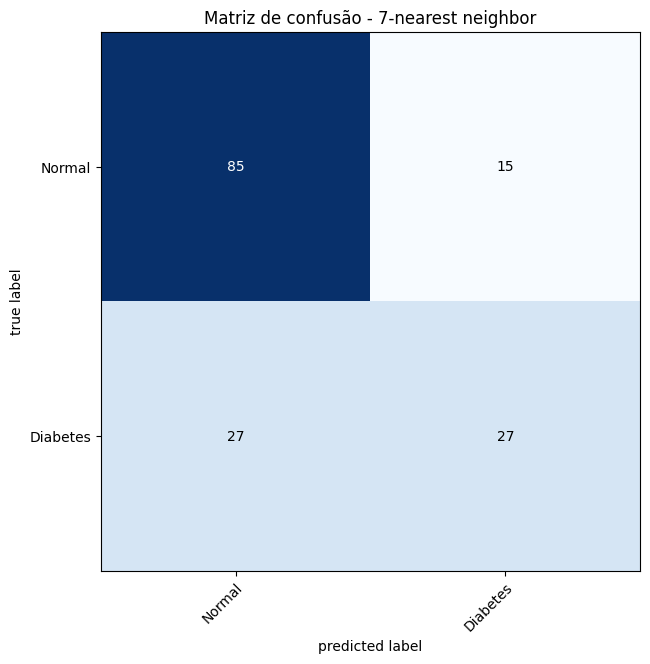

              precision    recall  f1-score   support

      Normal       0.76      0.85      0.80       100
    Diabetes       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154

F1-score no conjunto de teste (kNN): 0.6822


In [ ]:
#determina o melhor k
best_k = np.argmax(f1_val) + 1
print(f'Melhor número de vizinhos: {best_k}')

clf = KNeighborsClassifier(best_k, weights=weights)

""" Faz o treinamento do classificador usando todas as amostras disponíveis (treinamento + validação)"""
clf.fit(X_train_scaled,y_train)

#obtém as estimativas para o conjunto de teste
knn_pred_test = clf.predict(X_test_scaled)

#exibe a matriz de confusão para o conjunto de teste
confmat = confusion_matrix(y_true=y_test,
                           y_pred=knn_pred_test)

from mlxtend.plotting import plot_confusion_matrix

fig, ax = plot_confusion_matrix(
    conf_mat=confmat, # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10,7)
)
plt.title(f'Matriz de confusão - {best_k}-nearest neighbor')
plt.show()

print(classification_report(y_true=y_test,
                            y_pred=knn_pred_test,
                            target_names=class_names))

print(f"F1-score no conjunto de teste (kNN): {f1_score(y_true=y_test,y_pred=knn_pred_test,average='macro'):.4f}")

### 4.3 Curva ROC

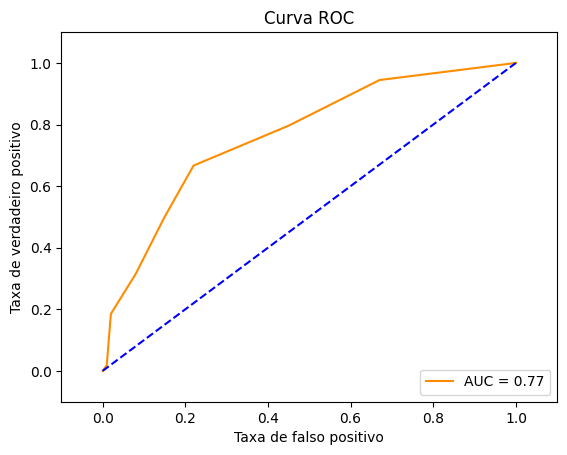

In [ ]:
""" Curva ROC """

from sklearn.metrics import roc_curve, auc

y_probs_test = clf.predict_proba(X_test_scaled)

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_probs_test[:,1])
roc_auc = auc(false_positive_rate, true_positive_rate)
plt.title('Curva ROC')
plt.plot(false_positive_rate, true_positive_rate, color='darkorange',label=f'AUC = {roc_auc:.2f}')
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'b--')
plt.ylim([-0.1, 1.1])
plt.xlim([-0.1, 1.1])
plt.ylabel('Taxa de verdadeiro positivo')
plt.xlabel('Taxa de falso positivo')
plt.show()


## 5. *k-fold* para monitorar o desempenho na validação em função do número de vizinhos mais próximos

Situação dos dados:
- `X_train_scaled` e `y_train`: partição completa para treinamento
- `X_test_scaled` e `y_test`: partição reservada para teste

In [ ]:
#k-fold CV
num_fold = 5
kf = KFold(n_splits=num_fold,shuffle=True,random_state=3)

# Define the parameter grid
param_grid = {
    'n_neighbors': np.arange(1,max_k+1),
    #'weights': ['uniform','distance'],
    #'p': [1,2,4],
}


""" Cria um objeto GridSearchCV

  - refit = True: ao final da busca em grade, retreina o modelo usando todos os dados disponíveis e os valores "ótimos" dos hiperparâmetros
    -> a versão ideal do estimador pode ser acessada via: best_estimator_

"""
grid = GridSearchCV(KNeighborsClassifier(), param_grid, refit=True, verbose=2,cv=num_fold,scoring='f1_macro')

# Fit the model
grid.fit(X_train_scaled, y_train)

# Exibe os melhores hiperparâmetros encontrados e o score ótimo de validação
print("Best parameters found: ", grid.best_params_)
print("Métrica de avaliação: ", grid.scorer_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=3; total time=   0.0s
[CV] END ......................................

### 5.1 Exibe a progressão da média de desempenho na validação em função de *k*

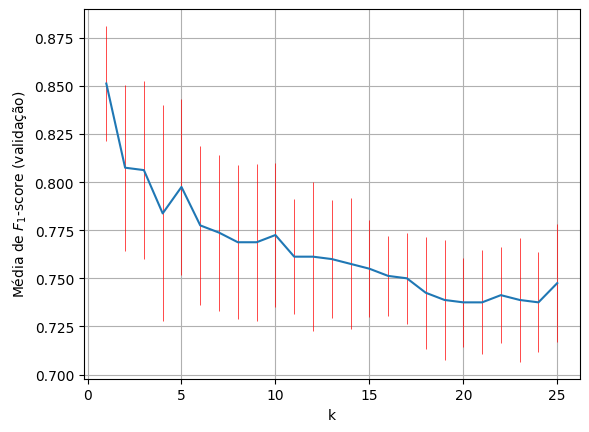

In [ ]:
cv_frame = pd.DataFrame(grid.cv_results_)

plt.errorbar(np.arange(1,max_k+1),cv_frame['mean_test_score'].values,yerr=cv_frame['std_test_score'].values,ecolor='r',elinewidth=0.5)
plt.grid(True)
plt.xlabel('k')
plt.ylabel('Média de $F_1$-score (validação)')
plt.show()

### 5.2 Aplica a melhor versão do kNN ao conjunto de teste

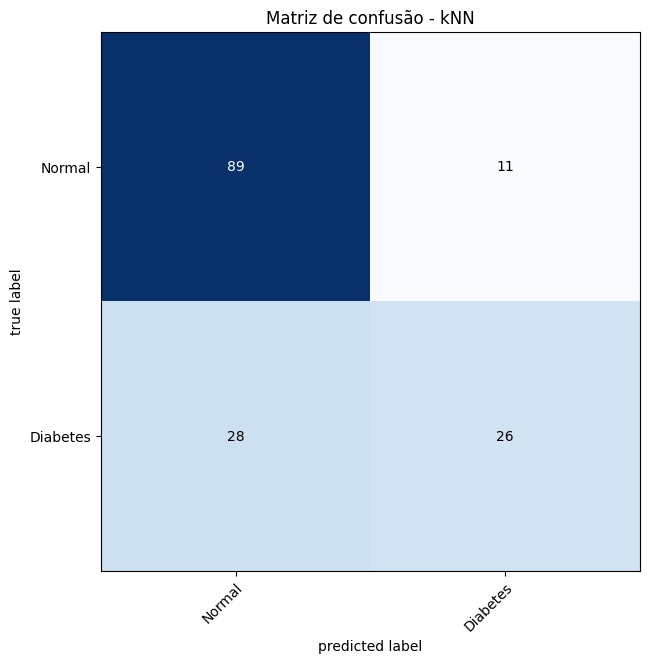

              precision    recall  f1-score   support

      Normal       0.76      0.89      0.82       100
    Diabetes       0.70      0.48      0.57        54

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.73       154

F1-score no conjunto de teste (kNN)): 0.6959


In [ ]:
best_kNN = grid.best_estimator_

#obtém as estimativas para o conjunto de teste
kNN_pred_test = best_kNN.predict(X_test_scaled)

#exibe a matriz de confusão para o conjunto de teste
confmat = confusion_matrix(y_true=y_test,
                           y_pred=kNN_pred_test)

from mlxtend.plotting import plot_confusion_matrix

fig, ax = plot_confusion_matrix(
    conf_mat=confmat, # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10,7)
)
plt.title(f'Matriz de confusão - kNN')
plt.show()

print(classification_report(y_true=y_test,
                            y_pred=kNN_pred_test,
                            target_names=class_names))

print(f"F1-score no conjunto de teste (kNN)): {f1_score(y_true=y_test,y_pred=kNN_pred_test,average='macro'):.4f}")

### 5.3 Generalizamos a busca de hiperparâmetros

In [ ]:
#k-fold CV
num_fold = 5
kf = KFold(n_splits=num_fold,shuffle=True,random_state=3)

# Define the parameter grid
param_grid = {
    'n_neighbors': np.arange(1,max_k+1),
    'weights': ['uniform','distance'],
    'p': [1,2,4,10],
}


""" Cria um objeto GridSearchCV

  - refit = True: ao final da busca em grade, retreina o modelo usando todos os dados disponíveis e os valores "ótimos" dos hiperparâmetros
    -> a versão ideal do estimador pode ser acessada via: best_estimator_

"""
grid = GridSearchCV(KNeighborsClassifier(), param_grid, refit=True, verbose=2,cv=num_fold)

# Fit the model
grid.fit(X_train_scaled, y_train)

# Exibe os melhores hiperparâmetros encontrados e o score ótimo de validação
print("Best parameters found: ", grid.best_params_)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END ................n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END ...............n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END ................n_neighbors=1, p=2, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=1, p=2, 

### 5.4 Aplica a melhor versão do kNN ao conjunto de teste após busca completa de hiperparâmetros

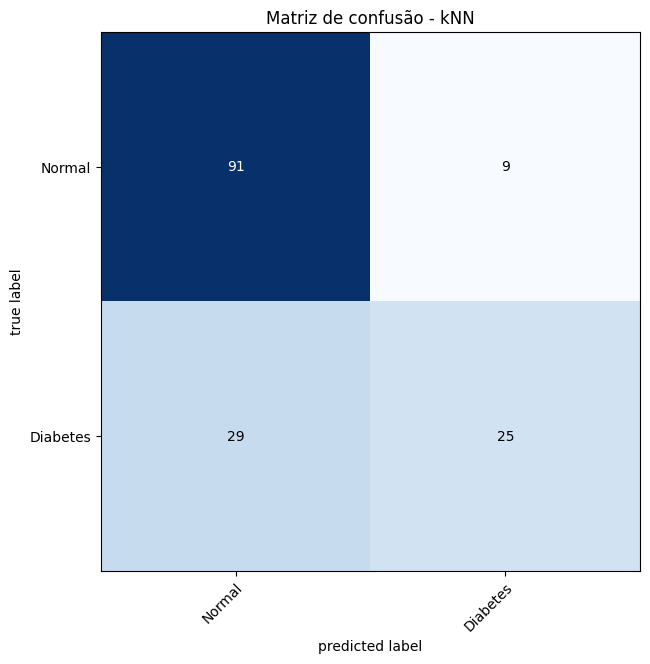

              precision    recall  f1-score   support

      Normal       0.76      0.91      0.83       100
    Diabetes       0.74      0.46      0.57        54

    accuracy                           0.75       154
   macro avg       0.75      0.69      0.70       154
weighted avg       0.75      0.75      0.74       154

F1-score no conjunto de teste (kNN)): 0.6977


In [ ]:
best_kNN = grid.best_estimator_

#obtém as estimativas para o conjunto de teste
kNN_pred_test = best_kNN.predict(X_test_scaled)

#exibe a matriz de confusão para o conjunto de teste
confmat = confusion_matrix(y_true=y_test,
                           y_pred=kNN_pred_test)

from mlxtend.plotting import plot_confusion_matrix

fig, ax = plot_confusion_matrix(
    conf_mat=confmat, # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10,7)
)
plt.title(f'Matriz de confusão - kNN')
plt.show()

print(classification_report(y_true=y_test,
                            y_pred=kNN_pred_test,
                            target_names=class_names))

print(f"F1-score no conjunto de teste (kNN)): {f1_score(y_true=y_test,y_pred=kNN_pred_test,average='macro'):.4f}")

## 6. Bônus: aplicação do SMOTE para balancear o *dataset*

Entrada:
```
    X_train_scaled, y_train
    X_test_scaled, y_test
```

In [ ]:
#cria um objeto da classe SMOTE
sm = SMOTE(random_state=42)

#dataset após a reamostragem
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

In [ ]:
#k-fold CV
num_fold = 5
kf = KFold(n_splits=num_fold,shuffle=True,random_state=3)

# Define the parameter grid
param_grid = {
    'n_neighbors': np.arange(1,max_k+1),
}


""" Cria um objeto GridSearchCV

  - refit = True: ao final da busca em grade, retreina o modelo usando todos os dados disponíveis e os valores "ótimos" dos hiperparâmetros
    -> a versão ideal do estimador pode ser acessada via: best_estimator_

"""
grid = GridSearchCV(KNeighborsClassifier(), param_grid, refit=True, verbose=2,cv=num_fold,scoring='f1_macro')

# Fit the model
grid.fit(X_res, y_res)

# Exibe os melhores hiperparâmetros encontrados e o score ótimo de validação
print("Best parameters found: ", grid.best_params_)
print("Métrica de avaliação: ", grid.scorer_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=3; total time=   0.0s
[CV] END ......................................

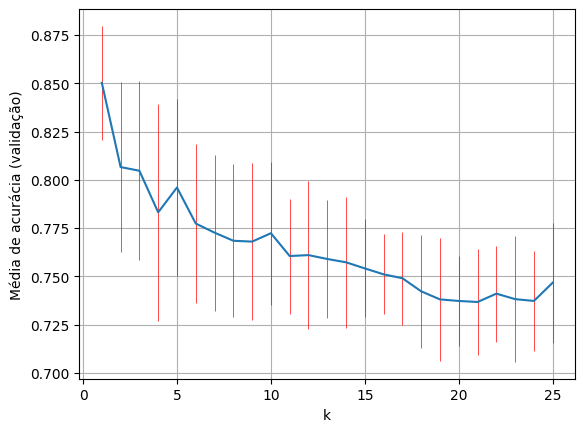

In [ ]:
cv_frame = pd.DataFrame(grid.cv_results_)

plt.errorbar(np.arange(1,max_k+1),cv_frame['mean_test_score'].values,yerr=cv_frame['std_test_score'].values,ecolor='r',elinewidth=0.5)
plt.grid(True)
plt.xlabel('k')
plt.ylabel('Média de acurácia (validação)')
plt.show()

KNeighborsClassifier(n_neighbors=np.int64(1))

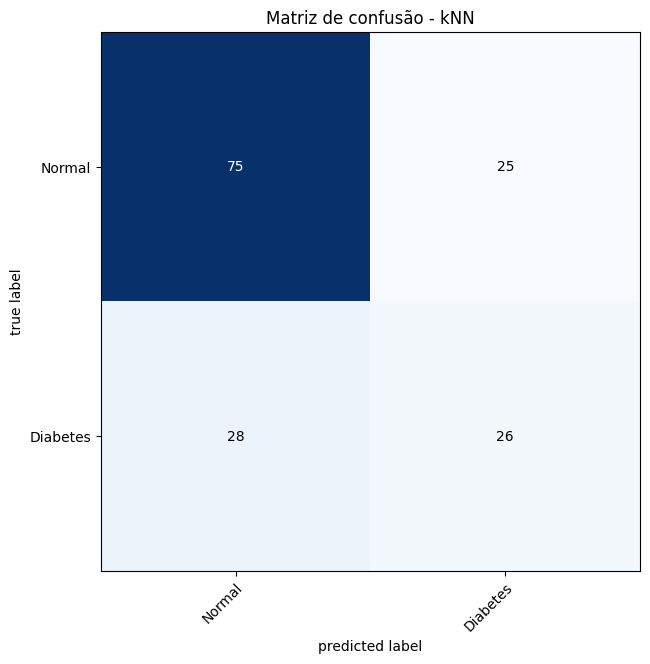

              precision    recall  f1-score   support

      Normal       0.73      0.75      0.74       100
    Diabetes       0.51      0.48      0.50        54

    accuracy                           0.66       154
   macro avg       0.62      0.62      0.62       154
weighted avg       0.65      0.66      0.65       154

F1-score no conjunto de teste (kNN)): 0.6171


In [ ]:
best_kNN = grid.best_estimator_

#obtém as estimativas para o conjunto de teste
kNN_pred_test = best_kNN.predict(X_test_scaled)

#exibe a matriz de confusão para o conjunto de teste
confmat = confusion_matrix(y_true=y_test,
                           y_pred=kNN_pred_test)

from mlxtend.plotting import plot_confusion_matrix

fig, ax = plot_confusion_matrix(
    conf_mat=confmat, # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10,7)
)
plt.title(f'Matriz de confusão - kNN')
plt.show()

print(classification_report(y_true=y_test,
                            y_pred=kNN_pred_test,
                            target_names=class_names))

print(f"F1-score no conjunto de teste (kNN)): {f1_score(y_true=y_test,y_pred=kNN_pred_test,average='macro'):.4f}")

O balanceamento feito na etapa de treinamento não se mostrou útil para determinar um classificador mais adequado. No caso do kNN, as amostras extras passam a fazer parte do modelo e são usadas durante a procura pelos $k$ vizinhos mais próximos na fase de teste.